# Phase4. Single Factor Testing

## 1.1 Loading Data & Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import json
import pandas as pd

data_dir = Path('data/alpha_inputs')
manifest_path = data_dir / 'manifest.json'
manifest = json.loads(manifest_path.read_text())
fmt = manifest.get('format')
files = manifest.get('files', {})

dataframes = {}
for name, path_str in files.items():
    path = Path(path_str)
    if fmt == 'parquet':
        dataframes[name] = pd.read_parquet(path)
    elif fmt == 'pickle':
        dataframes[name] = pd.read_pickle(path)
    else:
        raise ValueError(f'Unknown data format: {fmt}')

globals().update(dataframes)


In [3]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [4]:
%run "./Factors.ipynb"

## 1.2 Alpha Metrics

In [5]:
# Print Performance Metrics
def performance_summary(pnl: pd.Series, periods_per_year: int = 252):
    pnl = pnl.dropna()
    # Skip the Training Period
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]

    n = len(pnl)

    # cumulative equity (start at 1.0)
    equity = (1 + pnl).cumprod()

    # total return
    total_return = equity.iloc[-1] - 1.0

    # CAGR
    years = n / periods_per_year
    if years > 0:
        cagr = equity.iloc[-1] ** (1 / years) - 1
    else:
        cagr = np.nan

    # annualized volatility
    ann_vol = pnl.std(ddof=1) * np.sqrt(periods_per_year)

    # Sharpe
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    # drawdowns
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    # Calmar
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # hit rate
    hit_rate = (pnl > 0).mean()

    print("===== Performance Summary =====")
    print(f"Periods             : {n}")
    print(f"Total Return        : {total_return:8.2%}")
    print(f"CAGR                : {cagr:8.2%}")
    print(f"Ann. Volatility     : {ann_vol:8.2%}")
    print(f"Sharpe Ratio        : {sharpe:8.2f}")
    print(f"Max Drawdown        : {max_dd:8.2%}")
    print(f"Calmar Ratio        : {calmar:8.2f}")
    print(f"Hit Rate (p>0)      : {hit_rate:8.2%}")

In [6]:
# Plot Equity Backtest Curve
def plot_equity_curve(pnl: pd.Series, title: str = "Equity Curve"):
    pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()

    # trim leading zeros
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]
        
    equity = (1 + pnl).cumprod()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(equity.index, equity.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity (start = 1.0)")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## 1.3 Data Pre-Processors

### 1.3.1 Outlier Clipper

In [1]:
def clip_outliers(df, n_std=3.0):
    """
    For each timestamp (row), clip values to mean ± n_std * std.
    """
    out = df.copy().astype(float)
    for time in out.index:
        row = out.loc[time].values.astype(float)
        mask = np.isfinite(row)
        if mask.sum() == 0:
            continue
        vals = row[mask]
        mu = vals.mean()
        sigma = vals.std(ddof=1)
        if sigma == 0 or not np.isfinite(sigma):
            continue
        lo = mu - n_std * sigma
        hi = mu + n_std * sigma
        out.loc[time] = np.clip(row, lo, hi)
    return out

### 1.3.2 Standardization

In [2]:
def standardize(df):
    out = df.copy().astype(float)
    for time in out.index:
        row = out.loc[time].values.astype(float)
        mask = np.isfinite(row)
        if mask.sum() == 0:
            continue
        vals = row[mask]
        mu = vals.mean()
        sigma = vals.std(ddof=1)
        if sigma == 0 or not np.isfinite(sigma):
            out.loc[time, mask] = 0.0
            continue
        z = (row - mu) / sigma
        out.loc[time] = z
    return out


### 1.3.3 Neutralization

## 1.4 Analytics

In [8]:
def factor_forward_returns_wide(alpha_df, close_df, periods=(1, 5, 10), min_assets=5):
    """
    Use original wide format (index=dates, columns=assets).
    Returns:
      - factor_aligned (DataFrame)
      - fwd_returns (dict of DataFrames)
      - ic (DataFrame: index=dates, columns=periods)
    """
    # align dates/assets
    common_dates = alpha_df.index.intersection(close_df.index)
    common_assets = alpha_df.columns.intersection(close_df.columns)
    factor = alpha_df.loc[common_dates, common_assets].astype(float)
    prices = close_df.loc[common_dates, common_assets].astype(float)

    # forward returns
    fwd_returns = {}
    for p in periods:
        fwd = prices.pct_change(p).shift(-p)
        # mask where factor is missing
        fwd = fwd.where(factor.notna())
        fwd_returns[p] = fwd

    # IC per date (Spearman)
    ic = pd.DataFrame(index=factor.index, columns=list(periods), dtype=float)
    for p, fwd in fwd_returns.items():
        for dt in factor.index:
            x = factor.loc[dt]
            y = fwd.loc[dt]
            mask = x.notna() & y.notna()
            if mask.sum() < min_assets:
                ic.at[dt, p] = np.nan
                continue
            ic.at[dt, p] = x[mask].rank().corr(y[mask].rank())

    return factor, fwd_returns, ic

## 2.1 Alpha 0617a

In [13]:
def make_weights(alpha_row):
    "Convert 1D alpha (for one date) into long-short weights."
    a = alpha_row.copy()
    a = a.replace([np.inf, -np.inf], np.nan)
    a = a.fillna(0.0)

    a = a - a.mean()
    # scale so sum(|w|) = 1
    denom = a.abs().sum()    
    return a / denom

In [10]:
alpha_pv1 = alpha_0617a(open_df,volume_df)

In [11]:
alpha_pv1.tail()

,ABI.BR,AD.AS,ADSGn.DE,ADYEN.AS,AIR.PA,AIRP.PA,ALVG.DE,ARGX.BR,ASML.AS,AXAF.PA,...,SAN.MC,SAPG.DE,SASY.PA,SCHN.PA,SGEF.PA,SGOB.PA,SIEGn.DE,TTEF.PA,VOWG_p.DE,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,-0.146329,-0.319329,-0.216151,-0.345088,-0.321676,-0.139359,-0.157522,-0.105351,-0.305027,-0.359413,...,-0.145419,-0.146186,-0.081926,-0.351116,-0.397242,-0.349127,-0.244297,-0.177871,-0.021627,-0.106051
2025-12-24,-0.146329,-0.483979,-0.216151,-0.180438,-0.321676,-0.139359,-0.157522,-0.105351,-0.140377,-0.359413,...,-0.145419,-0.146186,-0.081926,-0.186466,-0.397242,-0.349127,-0.244297,-0.177871,-0.021627,-0.106051
2025-12-29,-0.146329,-0.331513,-0.216151,-0.332904,-0.321676,-0.139359,-0.157522,-0.105351,-0.292843,-0.511879,...,-0.145419,-0.146186,-0.081926,-0.186466,-0.549707,-0.349127,-0.244297,-0.177871,-0.021627,-0.106051
2025-12-30,-0.318539,-0.331513,-0.216151,-0.505114,-0.149466,-0.139359,-0.157522,-0.105351,-0.292843,-0.339669,...,-0.145419,-0.146186,-0.081926,-0.014257,-0.377497,-0.349127,-0.244297,-0.177871,-0.021627,-0.106051
2025-12-31,-0.318539,-0.331513,-0.216151,-0.339276,-0.315304,-0.139359,-0.157522,-0.105351,-0.292843,-0.339669,...,-0.145419,-0.146186,-0.081926,-0.014257,-0.543335,-0.349127,-0.244297,-0.177871,-0.021627,-0.106051


In [13]:
factor, fwd, ic = factor_forward_returns_wide(alpha_pv1, close_df, periods=(1,5,10))

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94472/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(p).shift(-p)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94472/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(p).shift(-p)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94472/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling

In [15]:
# Backtest
fwd_ret = close_df.shift(-1) / close_df - 1.0

# align shapes: drop last row (no forward return)
alpha_panel = alpha_pv1
alpha_panel = alpha_panel.iloc[:-1, :]
fwd_ret     = fwd_ret.iloc[:-1, :]

# Apply weights and compute pnl
weights = alpha_panel.apply(make_weights, axis=1)  # same shape as alpha_panel
daily_pnl = (weights * fwd_ret).sum(axis=1)

In [16]:
performance_summary(daily_pnl,252)

===== Performance Summary =====
Periods             : 2228
Total Return        :   34.54%
CAGR                :    3.41%
Ann. Volatility     :    4.44%
Sharpe Ratio        :     0.77
Max Drawdown        :   -5.15%
Calmar Ratio        :     0.66
Hit Rate (p>0)      :   52.33%


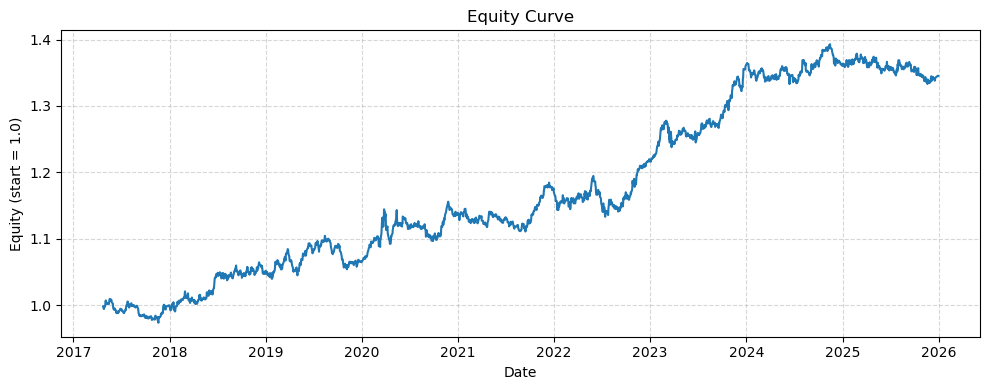

In [17]:
plot_equity_curve(daily_pnl,"Equity Curve")

## 2.2 Alpha 0810a

In [188]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [189]:
alpha2 = alpha_0810a(returns_df,cap_df,volume_df)

In [190]:
alpha2.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,NaN,-0.7,-0.5,-0.739479,-0.316076,-0.7,-0.316076,-0.739479,-0.316076,-0.739479,...,-0.5,-0.316076,-0.316076,NaN,-0.316076,NaN,-0.739479,-0.316076,-0.739479,-0.316076
2025-11-25,NaN,-0.7,-0.5,-0.734344,-0.312121,-0.7,-0.312121,-0.734344,-0.312121,-0.734344,...,-0.5,-0.312121,-0.312121,NaN,-0.312121,NaN,-0.734344,-0.312121,-0.734344,-0.312121
2025-11-26,NaN,-0.7,-0.5,-0.734344,-0.312121,-0.7,-0.312121,-0.734344,-0.312121,-0.734344,...,-0.5,-0.312121,-0.312121,NaN,-0.312121,NaN,-0.734344,-0.312121,-0.734344,-0.312121
2025-11-27,NaN,-0.7,-0.5,-0.734344,-0.312121,-0.7,-0.312121,-0.734344,-0.312121,-0.734344,...,-0.5,-0.312121,-0.312121,NaN,-0.312121,NaN,-0.734344,-0.312121,-0.734344,-0.312121
2025-11-28,NaN,-0.7,-0.5,-0.734344,-0.312121,-0.7,-0.312121,-0.734344,-0.312121,-0.734344,...,-0.5,-0.312121,-0.312121,NaN,-0.312121,NaN,-0.734344,-0.312121,-0.734344,-0.312121


In [191]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel2 = alpha2
alpha_panel2 = alpha_panel2.iloc[:-1, :]

# Apply weights and compute pnl
weights2 = alpha_panel2.apply(make_weights, axis=1)
daily_pnl2 = (weights2 * fwd_ret).sum(axis=1)

In [192]:
performance_summary(daily_pnl2,252)

===== Performance Summary =====
Periods             : 2446
Total Return        :   25.07%
CAGR                :    2.33%
Ann. Volatility     :    4.29%
Sharpe Ratio        :     0.54
Max Drawdown        :   -7.42%
Calmar Ratio        :     0.31
Hit Rate (p>0)      :   52.53%


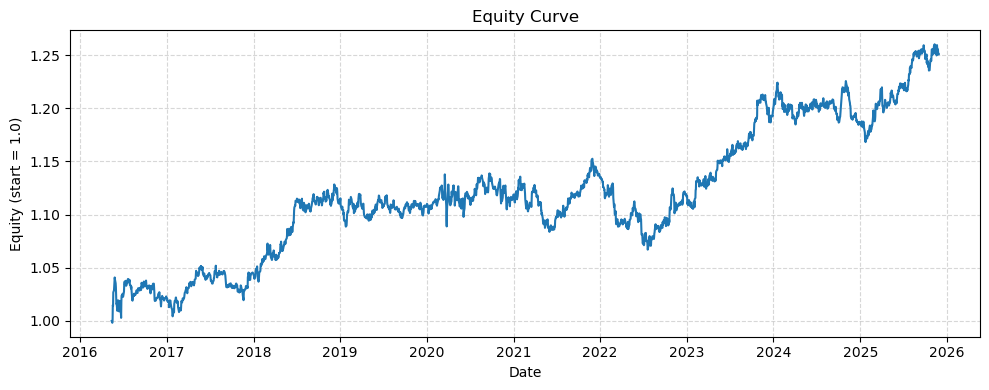

In [193]:
plot_equity_curve(daily_pnl2,"Equity Curve")

## 2.3 Alpha 0415b

In [194]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [195]:
alpha3 = alpha_0415b(close_df,volume_df)

In [196]:
alpha3.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,NaN,-0.195309,-0.239054,-0.149012,-0.171850,-0.325574,-0.190039,-0.211765,-0.269246,-0.326411,...,-0.253358,-0.152516,-0.215165,NaN,-0.055332,NaN,-0.189286,-0.431426,-0.151732,-0.373628
2025-11-25,NaN,-0.195619,-0.239364,-0.149012,-0.172160,-0.325264,-0.190349,-0.211765,-0.268936,-0.326411,...,-0.253048,-0.152826,-0.214855,NaN,-0.055332,NaN,-0.189596,-0.431426,-0.152042,-0.373318
2025-11-26,NaN,-0.195929,-0.239054,-0.149012,-0.172470,-0.325574,-0.190660,-0.211765,-0.268626,-0.326411,...,-0.252737,-0.152516,-0.215165,NaN,-0.055332,NaN,-0.189286,-0.431426,-0.152352,-0.373008
2025-11-27,NaN,-0.195619,-0.238744,-0.149012,-0.172780,-0.325884,-0.190970,-0.211765,-0.268316,-0.326411,...,-0.252427,-0.152205,-0.215475,NaN,-0.055332,NaN,-0.188975,-0.431426,-0.152042,-0.372698
2025-11-28,NaN,-0.195309,-0.239054,-0.149012,-0.173091,-0.325574,-0.191280,-0.211765,-0.268626,-0.326411,...,-0.252117,-0.151895,-0.215785,NaN,-0.055332,NaN,-0.189286,-0.431426,-0.151732,-0.373008


In [197]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel3 = alpha3
alpha_panel3 = alpha_panel3.iloc[:-1, :]

# Apply weights and compute pnl
weights3 = alpha_panel3.apply(make_weights, axis=1)
daily_pnl3 = (weights3 * fwd_ret).sum(axis=1)

In [198]:
performance_summary(daily_pnl3,252)

===== Performance Summary =====
Periods             : 2203
Total Return        :   35.90%
CAGR                :    3.57%
Ann. Volatility     :    4.65%
Sharpe Ratio        :     0.77
Max Drawdown        :  -12.70%
Calmar Ratio        :     0.28
Hit Rate (p>0)      :   53.11%


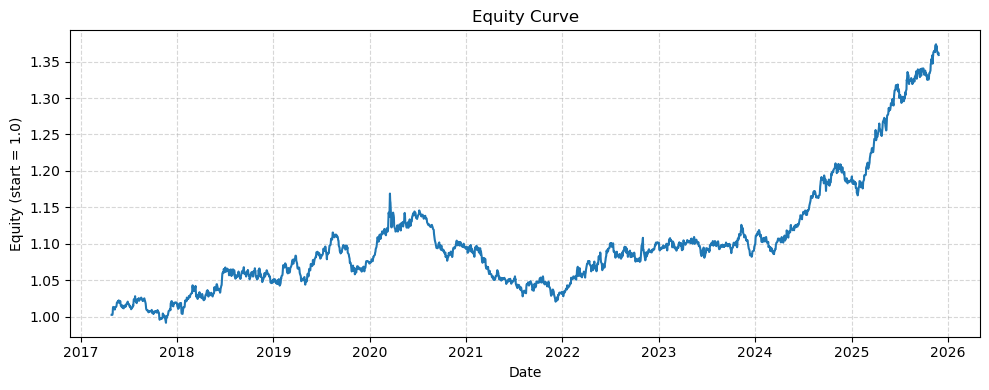

In [199]:
plot_equity_curve(daily_pnl3,"Equity Curve")

## 2.4 Alpha 0616a

In [200]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [201]:
alpha4 = alpha_0616a(close_df,open_df,volume_df)

In [202]:
alpha4.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,NaN,-0.271371,-0.212958,-0.220299,-0.192312,-0.230940,-0.355206,-0.239962,-0.139152,-0.086775,...,-0.067838,-0.160323,-0.118884,NaN,-0.122864,NaN,-0.133422,-0.175817,-0.245634,-0.024848
2025-11-25,NaN,-0.257178,-0.227150,-0.220299,-0.206505,-0.245133,-0.369398,-0.239962,-0.124959,-0.086775,...,-0.082031,-0.174515,-0.133076,NaN,-0.122864,NaN,-0.147615,-0.175817,-0.259826,-0.039040
2025-11-26,NaN,-0.242773,-0.212745,-0.220299,-0.220910,-0.259538,-0.383804,-0.239962,-0.110554,-0.086775,...,-0.096436,-0.160110,-0.147481,NaN,-0.122864,NaN,-0.133209,-0.175817,-0.245421,-0.024635
2025-11-27,NaN,-0.257243,-0.227215,-0.220299,-0.235380,-0.274008,-0.398274,-0.239962,-0.096084,-0.086775,...,-0.110906,-0.145640,-0.147481,NaN,-0.122864,NaN,-0.147679,-0.175817,-0.230951,-0.039105
2025-11-28,NaN,-0.271930,-0.241902,-0.220299,-0.250067,-0.259321,-0.412961,-0.239962,-0.110771,-0.086775,...,-0.096219,-0.130952,-0.162168,NaN,-0.122864,NaN,-0.162366,-0.175817,-0.216264,-0.053792


In [203]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel4 = alpha4
alpha_panel4 = alpha_panel4.iloc[:-1, :]

# Apply weights and compute pnl
weights4 = alpha_panel4.apply(make_weights, axis=1)
daily_pnl4 = (weights4 * fwd_ret).sum(axis=1)

In [204]:
performance_summary(daily_pnl4,252)

===== Performance Summary =====
Periods             : 2203
Total Return        :   21.15%
CAGR                :    2.22%
Ann. Volatility     :    4.41%
Sharpe Ratio        :     0.50
Max Drawdown        :   -8.21%
Calmar Ratio        :     0.27
Hit Rate (p>0)      :   51.38%


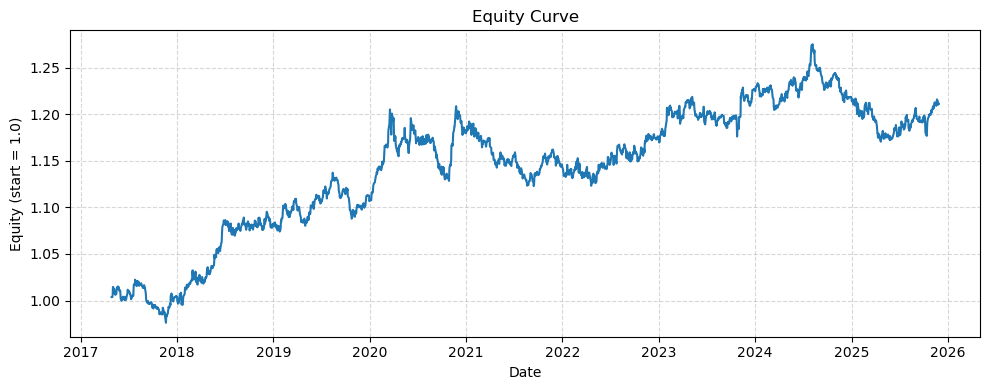

In [205]:
plot_equity_curve(daily_pnl4,"Equity Curve")

## 2.5 Alpha0812a

In [206]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [207]:
alpha5 = alpha_0812a(liabilities_df,assets_df,debt_df,equity_df)

In [208]:
alpha5.tail()

Total Liabilities,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,141469.713795,92204.278987,121024.841636,141469.713795,141469.713795,92204.278987,141469.713795,92204.278987,141469.713795,135046.428413,...,136029.314499,92204.278987,141469.713795,141469.713795,141469.713795,141469.713795,92204.278987,92204.278987,92204.278987,141469.713795
2025-11-25,141693.891563,92432.334333,121558.577886,141693.891563,141693.891563,92432.334333,141693.891563,92432.334333,141693.891563,135642.001797,...,136029.314499,92432.334333,141693.891563,141693.891563,141693.891563,141693.891563,92432.334333,92432.334333,92432.334333,141693.891563
2025-11-26,141919.010524,92660.977551,122093.488474,141919.010524,141919.010524,92660.977551,141919.010524,92660.977551,141919.010524,136238.885572,...,136029.314499,92660.977551,141919.010524,141919.010524,141919.010524,141919.010524,92660.977551,92660.977551,92660.977551,141919.010524
2025-11-27,142145.072501,92890.206817,122629.573399,142145.072501,142145.072501,92890.206817,142145.072501,92890.206817,142145.072501,136837.079740,...,136029.314499,92890.206817,142145.072501,142145.072501,142145.072501,142145.072501,92890.206817,92890.206817,92890.206817,142145.072501
2025-11-28,142372.079320,93120.020306,123166.832661,142372.079320,142372.079320,93120.020306,142372.079320,93120.020306,142372.079320,137436.584301,...,136029.314499,93120.020306,142372.079320,142372.079320,142372.079320,142372.079320,93120.020306,93120.020306,93120.020306,142372.079320


In [209]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel5 = alpha5
alpha_panel5 = alpha_panel5.iloc[:-1, :]

# Apply weights and compute pnl
weights5 = alpha_panel5.apply(make_weights, axis=1)
daily_pnl5 = (weights5 * fwd_ret).sum(axis=1)

In [210]:
performance_summary(daily_pnl5,252)

===== Performance Summary =====
Periods             : 2292
Total Return        :   28.84%
CAGR                :    2.82%
Ann. Volatility     :    4.42%
Sharpe Ratio        :     0.64
Max Drawdown        :   -8.30%
Calmar Ratio        :     0.34
Hit Rate (p>0)      :   51.27%


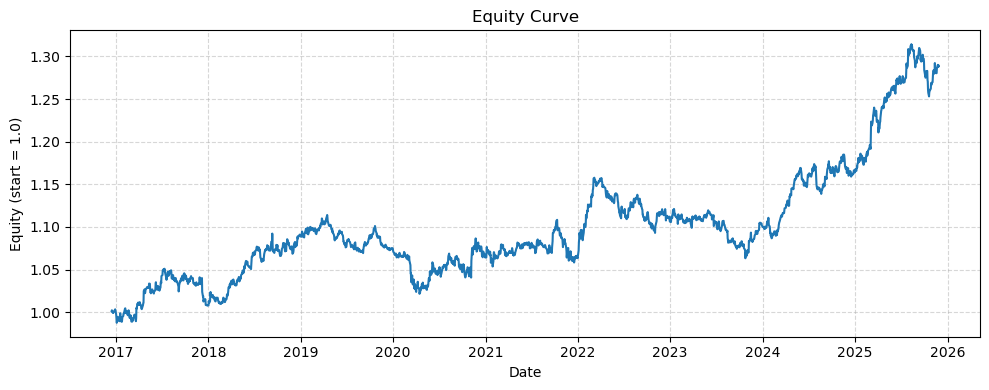

In [211]:
plot_equity_curve(daily_pnl5,'Equity Curve')

## 2.6 Alpha0612d

In [212]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [213]:
alpha6 = alpha_0612d(debt_df,assets_df,volume_df)

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_60112/1347696834.py:117:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [214]:
alpha6.tail()

Total Debt,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-1.315483e+08,0.0,-0.0
2025-11-25,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-1.315483e+08,0.0,-0.0
2025-11-26,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-1.315483e+08,0.0,-0.0
2025-11-27,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-1.315483e+08,0.0,-0.0
2025-11-28,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-1.315483e+08,0.0,-0.0


In [215]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel6 = alpha6
alpha_panel6 = alpha_panel6.iloc[:-1, :]

# Apply weights and compute pnl
weights6 = alpha_panel6.apply(make_weights, axis=1)
daily_pnl6 = (weights6 * fwd_ret).sum(axis=1)

In [216]:
performance_summary(daily_pnl6,252)

===== Performance Summary =====
Periods             : 2058
Total Return        :   37.73%
CAGR                :    4.00%
Ann. Volatility     :    8.81%
Sharpe Ratio        :     0.45
Max Drawdown        :  -19.63%
Calmar Ratio        :     0.20
Hit Rate (p>0)      :   42.27%


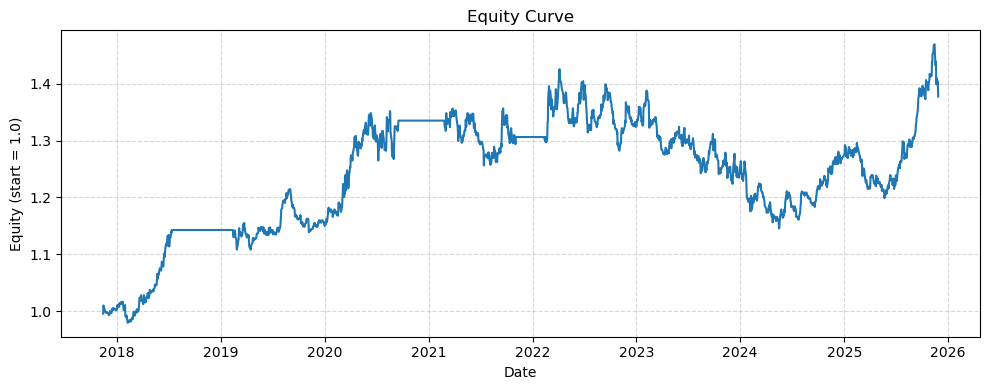

In [217]:
plot_equity_curve(daily_pnl6,"Equity Curve")

## 2.7 Alpha 0608d

In [218]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [219]:
alpha7 = alpha_0608d(close_df,open_df,volume_df,sharesout_df,industry,horro_window=10)

In [220]:
alpha7.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,-1.139259,-0.475591,-2.135383,-1.038241,-0.127292,-1.887888,0.204620,-0.716836,-0.566682,-1.299523,...,-1.036472,-0.059512,0.41131,-1.0,-0.982639,-1.015587,0.683076,-1.602729,-1.735955,1.172895
2025-11-25,-1.139259,1.034262,-2.135383,-1.038241,-0.127292,-1.887888,0.204620,-0.716836,-0.566682,-1.299523,...,-1.036472,-0.059512,0.41131,-1.0,-0.982639,-1.015587,0.683076,-1.602729,-1.735955,1.172895
2025-11-26,-1.139259,2.609554,-2.135383,-1.038241,-0.127292,-1.887888,-1.370672,-0.716836,-0.566682,-1.299523,...,-1.036472,-0.059512,0.41131,-1.0,-0.982639,-1.015587,0.683076,-1.602729,-1.735955,1.172895
2025-11-27,-1.139259,0.962631,-2.135383,-1.038241,-0.127292,-1.887888,-1.370672,-0.716836,-0.566682,-1.299523,...,-1.036472,-0.059512,0.41131,-1.0,-0.982639,-1.015587,-0.963848,-1.602729,-1.735955,-0.474028
2025-11-28,-1.139259,-0.478407,-2.135383,-1.038241,-0.127292,-1.887888,-1.370672,-0.716836,-0.566682,-1.299523,...,-1.036472,-0.059512,0.41131,-1.0,-0.982639,-1.015587,-0.963848,-1.602729,-1.735955,-0.474028


In [221]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel7 = alpha7
alpha_panel7 = alpha_panel7.iloc[:-1, :]

# Apply weights and compute pnl
weights7 = alpha_panel7.apply(make_weights, axis=1)
daily_pnl7 = (weights7 * fwd_ret).sum(axis=1)

In [222]:
performance_summary(daily_pnl7,252)

===== Performance Summary =====
Periods             : 2448
Total Return        :   76.43%
CAGR                :    6.02%
Ann. Volatility     :    7.45%
Sharpe Ratio        :     0.81
Max Drawdown        :  -16.25%
Calmar Ratio        :     0.37
Hit Rate (p>0)      :   51.63%


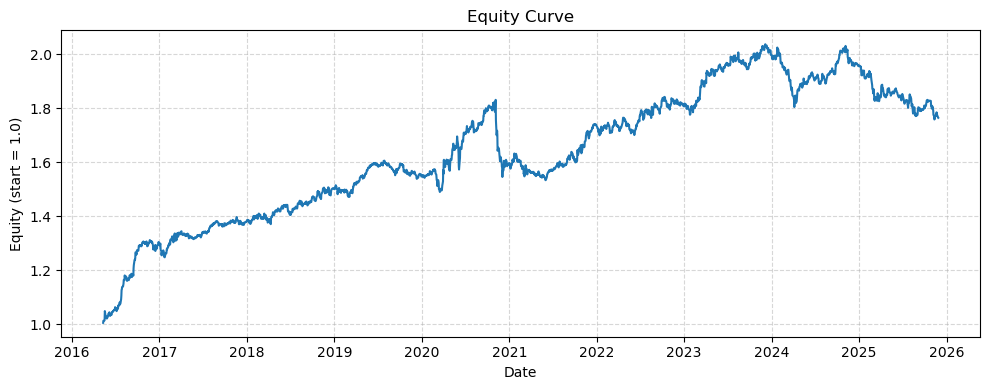

In [223]:
plot_equity_curve(daily_pnl7,"Equity Curve")

## 2.8 Alpha0615a

In [224]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [225]:
alpha8 = alpha_0615a(volume_df,sharesout_df,cap_df)

In [226]:
alpha8.tail()

Volume,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,1.583333,1.283879,1.193924,0.568845,1.613009,1.843894,1.084555,0.680877,1.268618,1.604015,...,1.738792,1.688335,1.533298,1.283333,1.761151,1.366667,1.329309,0.573038,1.473776,1.837085
2025-11-25,1.583333,1.272214,1.205589,0.568845,1.601345,1.832229,1.072891,0.680877,1.256953,1.604015,...,1.727127,1.676671,1.521634,1.283333,1.761151,1.366667,1.332232,0.573038,1.462111,1.828344
2025-11-26,1.583333,1.260588,1.217216,0.568845,1.589718,1.820602,1.061264,0.680877,1.245326,1.604015,...,1.715500,1.665044,1.510007,1.283333,1.761151,1.366667,1.343859,0.573038,1.450485,1.831263
2025-11-27,1.583333,1.248984,1.228819,0.568845,1.578115,1.808999,1.049661,0.680877,1.233723,1.604015,...,1.703897,1.653441,1.498404,1.283333,1.761151,1.366667,1.355462,0.573038,1.438881,1.834179
2025-11-28,1.583333,1.237404,1.240399,0.568845,1.566535,1.797419,1.038081,0.680877,1.222143,1.604015,...,1.692317,1.665021,1.486824,1.283333,1.761151,1.366667,1.367042,0.573038,1.450461,1.837094


In [227]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel8 = alpha8
alpha_panel8 = alpha_panel8.iloc[:-1, :]

# Apply weights and compute pnl
weights8 = alpha_panel8.apply(make_weights, axis=1)
daily_pnl8 = (weights8 * fwd_ret).sum(axis=1)

In [228]:
performance_summary(daily_pnl8,252)

===== Performance Summary =====
Periods             : 1774
Total Return        :   27.86%
CAGR                :    3.55%
Ann. Volatility     :    4.36%
Sharpe Ratio        :     0.81
Max Drawdown        :   -6.72%
Calmar Ratio        :     0.53
Hit Rate (p>0)      :   51.13%


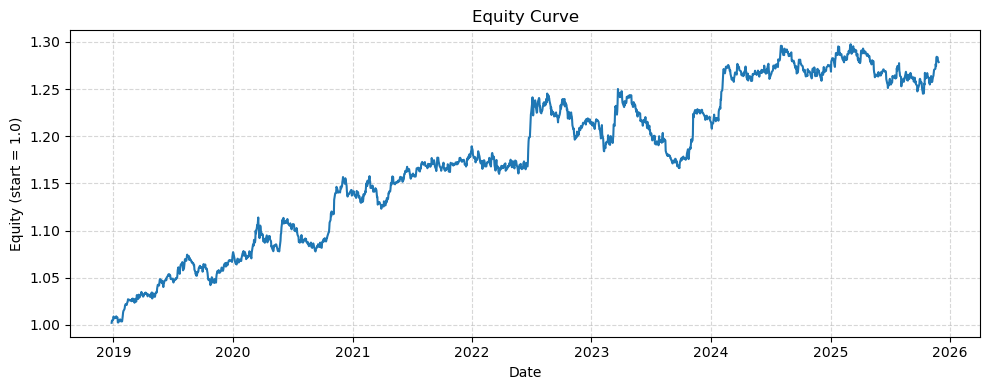

In [229]:
plot_equity_curve(daily_pnl8,"Equity Curve")

## 2.9 Alpha0604c

In [230]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [231]:
alpha9 = alpha_0604c(close_df,high_df,low_df)

In [232]:
alpha9.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,0.873064,0.878664,0.855815,0.884515,0.863582,0.859178,0.867362,0.883069,0.854556,0.866402,...,0.869565,0.864577,0.860839,0.872830,0.862685,0.876106,0.872624,0.863483,0.858035,0.848608
2025-11-25,0.872627,0.883864,0.855815,0.889684,0.863380,0.859178,0.867362,0.881880,0.853505,0.865861,...,0.869041,0.864379,0.860911,0.872376,0.862370,0.876001,0.872483,0.863598,0.857899,0.847695
2025-11-26,0.872195,0.883130,0.855815,0.889115,0.863375,0.859178,0.867362,0.880698,0.852673,0.865325,...,0.868725,0.864182,0.861052,0.871927,0.862058,0.875894,0.872343,0.863780,0.857765,0.846783
2025-11-27,0.871767,0.882403,0.855815,0.888550,0.863495,0.859250,0.867362,0.879522,0.851982,0.864793,...,0.868482,0.864060,0.861261,0.871483,0.861822,0.875786,0.872203,0.863957,0.857633,0.845870
2025-11-28,0.871344,0.881682,0.855815,0.887990,0.863613,0.859320,0.867362,0.878353,0.851428,0.864266,...,0.868240,0.864009,0.861535,0.871044,0.861588,0.875677,0.872062,0.864129,0.857503,0.844958


In [233]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel9 = alpha9
alpha_panel9 = alpha_panel9.iloc[:-1, :]

# Apply weights and compute pnl
weights9 = alpha_panel9.apply(make_weights, axis=1)
daily_pnl9 = (weights9 * fwd_ret).sum(axis=1)

In [234]:
performance_summary(daily_pnl9,252)

===== Performance Summary =====
Periods             : 2686
Total Return        :   32.05%
CAGR                :    2.64%
Ann. Volatility     :    6.02%
Sharpe Ratio        :     0.44
Max Drawdown        :  -18.41%
Calmar Ratio        :     0.14
Hit Rate (p>0)      :   51.49%


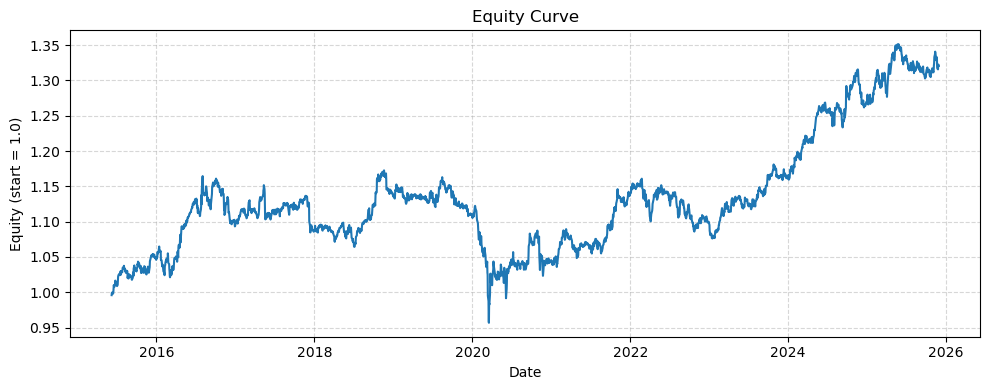

In [235]:
plot_equity_curve(daily_pnl9,"Equity Curve")

## 2.10 Alpha0407a

In [236]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [237]:
alpha10 = alpha_0407a(debt_df)

In [238]:
alpha10.tail()

Total Debt,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,...,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554
2025-11-25,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,...,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554
2025-11-26,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,...,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554
2025-11-27,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,...,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554
2025-11-28,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,...,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554,-7.27554


In [239]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel10 = alpha10
alpha_panel10 = alpha_panel10.iloc[:-1, :]

# Apply weights and compute pnl
weights10 = alpha_panel10.apply(make_weights, axis=1)
daily_pnl10 = (weights10 * fwd_ret).sum(axis=1)

In [240]:
performance_summary(daily_pnl10,252)

===== Performance Summary =====
Periods             : 2765
Total Return        :  179.51%
CAGR                :    9.82%
Ann. Volatility     :   14.41%
Sharpe Ratio        :     0.68
Max Drawdown        :  -21.41%
Calmar Ratio        :     0.46
Hit Rate (p>0)      :   52.69%


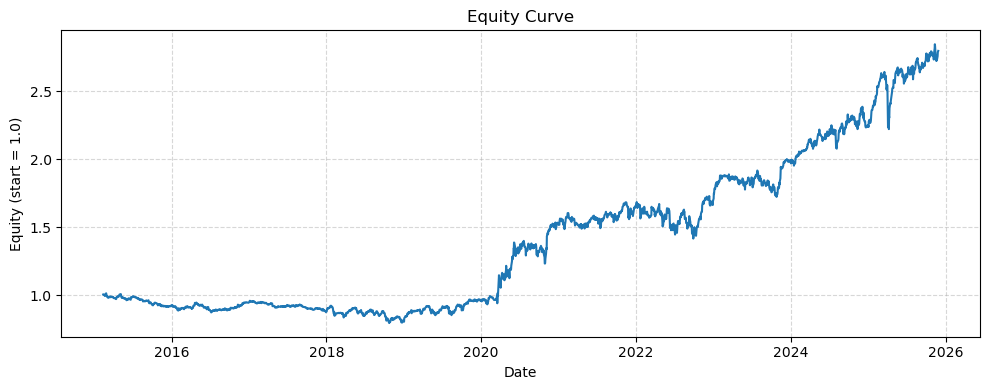

In [241]:
plot_equity_curve(daily_pnl10,"Equity Curve")

## 2.11 Alpha0505

In [242]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [243]:
alpha11 = alpha_0505(operating_income_df,vwap_df)

In [244]:
alpha11.tail()

,ABI.BR,AD.AS,ADSGn.DE,ADYEN.AS,AIR.PA,AIRP.PA,ALVG.DE,ARGX.BR,ASML.AS,AXAF.PA,...,SAN.MC,SAPG.DE,SASY.PA,SCHN.PA,SGEF.PA,SGOB.PA,SIEGn.DE,TTEF.PA,VOWG_p.DE,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,-1,-1,-1,2,-1,2,-1,2,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
2025-11-25,-1,-1,-1,2,-1,2,-1,2,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
2025-11-26,-1,-1,-1,2,-1,2,-1,2,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
2025-11-27,-1,-1,-1,-1,-1,2,-1,2,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
2025-11-28,-1,-1,-1,-1,-1,2,-1,2,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,2


In [245]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel11 = alpha11
alpha_panel11 = alpha_panel11.iloc[:-1, :]

# Apply weights and compute pnl
weights11 = alpha_panel11.apply(make_weights, axis=1)
daily_pnl11 = (weights11 * fwd_ret).sum(axis=1)

In [246]:
performance_summary(daily_pnl11,252)

===== Performance Summary =====
Periods             : 2304
Total Return        :   28.24%
CAGR                :    2.76%
Ann. Volatility     :    7.46%
Sharpe Ratio        :     0.37
Max Drawdown        :  -20.63%
Calmar Ratio        :     0.13
Hit Rate (p>0)      :   34.33%


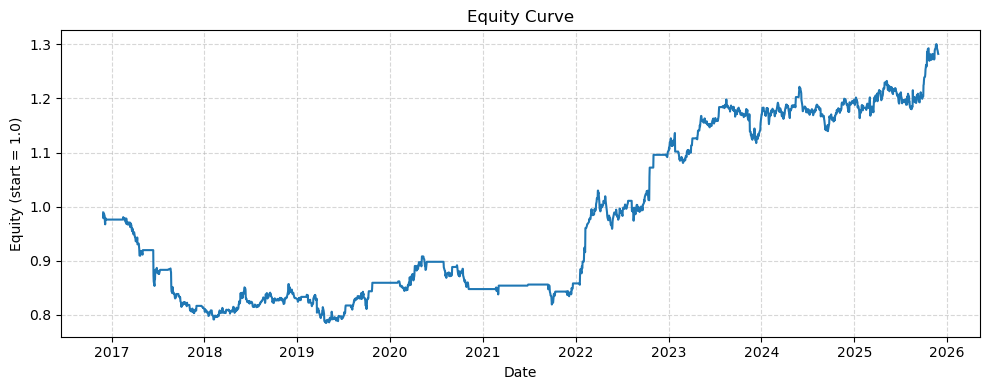

In [247]:
plot_equity_curve(daily_pnl11,"Equity Curve")

## 2.12 Alpha0413a

In [248]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [249]:
alpha12 = alpha_0413a(close_df,high_df,low_df)

In [250]:
alpha12.tail()

Price Close,ISP.MI,SAF.PA,TTEF.PA,RHMG.DE,SGEF.PA,LVMH.PA,IBE.MC,DTEGn.DE,SGOB.PA,BMWG.DE,...,SCHN.PA,ABI.BR,AXAF.PA,ENI.MI,BAYGn.DE,CRDI.MI,ASML.AS,SIEGn.DE,HRMS.PA,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-24,0.586957,0.956522,0.326087,0.739130,0.695652,0.913043,0.369565,NaN,0.826087,0.130435,...,NaN,0.891304,0.195652,0.869565,0.217391,0.760870,0.086957,0.239130,0.978261,0.717391
2025-11-25,0.280000,0.640000,0.400000,0.720000,0.520000,0.820000,0.600000,0.1800,0.220000,0.320000,...,0.740000,0.620000,0.700000,0.980000,0.680000,0.300000,0.840000,0.340000,0.420000,0.160000
2025-11-26,0.360000,0.240000,0.500000,0.860000,0.110000,0.720000,0.110000,0.8200,0.110000,0.680000,...,0.110000,0.980000,0.560000,0.460000,1.000000,0.700000,0.110000,0.740000,0.540000,0.620000
2025-11-27,0.740000,0.220000,0.540000,0.560000,0.500000,0.180000,0.460000,0.8000,0.520000,0.280000,...,0.380000,0.720000,0.120000,0.480000,0.360000,0.060000,0.980000,0.700000,0.900000,0.960000
2025-11-28,0.250000,0.833333,0.375000,0.979167,0.333333,0.291667,0.583333,0.3125,0.770833,0.708333,...,0.020833,NaN,0.437500,0.041667,0.937500,0.458333,0.229167,0.541667,NaN,0.479167


In [251]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel12 = alpha12
alpha_panel12 = alpha_panel12.iloc[:-1, :]

# Apply weights and compute pnl
weights12 = alpha_panel12.apply(make_weights, axis=1)
daily_pnl12 = (weights12 * fwd_ret).sum(axis=1)

In [252]:
performance_summary(daily_pnl12,252)

===== Performance Summary =====
Periods             : 2795
Total Return        :   -7.87%
CAGR                :   -0.74%
Ann. Volatility     :    5.26%
Sharpe Ratio        :    -0.14
Max Drawdown        :  -20.14%
Calmar Ratio        :    -0.04
Hit Rate (p>0)      :   50.41%


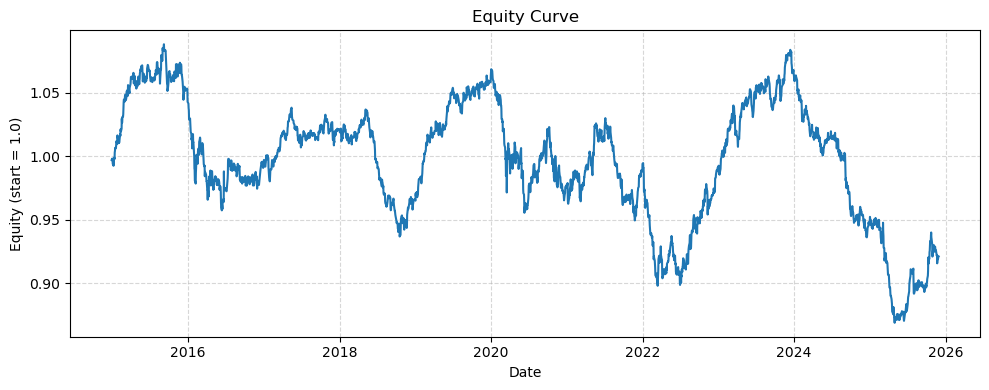

In [253]:
plot_equity_curve(daily_pnl12,"Equity Curve")

## 2.13 Alpha0413b

In [254]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [255]:
alpha13 = alpha_0413b(operating_income_df,cap_df)

In [256]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel13 = alpha13
alpha_panel13 = alpha_panel13.iloc[:-1, :]

# Apply weights and compute pnl
weights13 = alpha_panel13.apply(make_weights, axis=1)
daily_pnl13 = (weights13 * fwd_ret).sum(axis=1)

In [257]:
performance_summary(daily_pnl13,252)

===== Performance Summary =====
Periods             : 2725
Total Return        :   45.34%
CAGR                :    3.52%
Ann. Volatility     :    6.59%
Sharpe Ratio        :     0.53
Max Drawdown        :  -16.98%
Calmar Ratio        :     0.21
Hit Rate (p>0)      :   51.71%


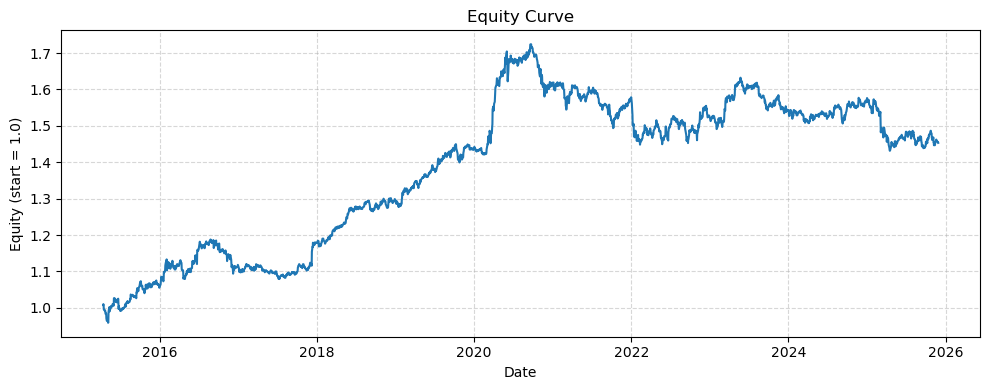

In [258]:
plot_equity_curve(daily_pnl13,"Equity Curve")

## 2.14 Alpha0503b

In [134]:
%run "~/Desktop/PitchBook/Multi-Factor L:S/Factor_Pool.ipynb"

In [135]:
alpha14 = alpha_0503b(sharesout_df,volume_df,vwap_df,low_df,open_df,high_df)

In [140]:
alpha14.head()

,ABI.BR,AD.AS,ADSGn.DE,ADYEN.AS,AIR.PA,AIRP.PA,ALVG.DE,ARGX.BR,ASML.AS,AXAF.PA,...,SAN.MC,SAPG.DE,SASY.PA,SCHN.PA,SGEF.PA,SGOB.PA,SIEGn.DE,TTEF.PA,VOWG_p.DE,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-30,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-02,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-05,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-06,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [137]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel14 = alpha14
alpha_panel14 = alpha_panel14.iloc[:-1, :]

# Apply weights and compute pnl
weights14 = alpha_panel14.apply(make_weights, axis=1)
daily_pnl14 = ((weights14 * fwd_ret).sum(axis=1).fillna(0.0))

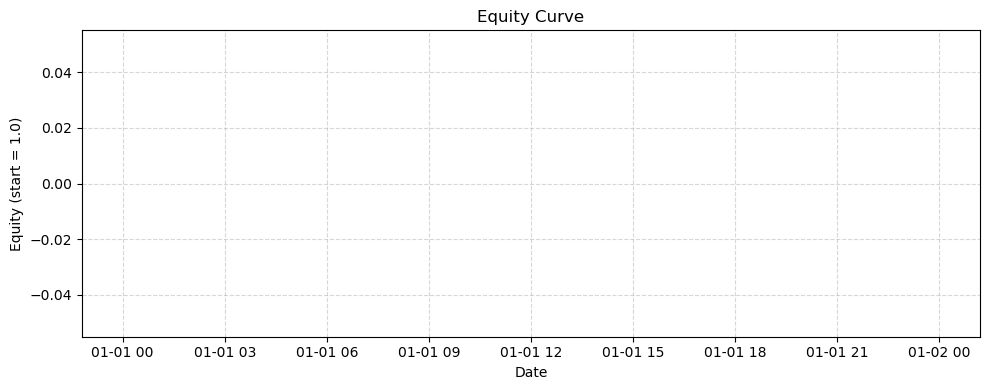

In [139]:
plot_equity_curve(daily_pnl14,"Equity Curve")